<a href="https://colab.research.google.com/github/ssleona67/Integracion-de-datos-y-prospectiva/blob/main/tendencia_central_y_dispercion_04082026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Caso de estudio:
##### EVERGREEN es un conglomerado taiwanés que opera en diversas industrias a nivel global. Su principal empresa, Evergreen Marine Corporation, se especializa en el  transporte marítimo de contenedores, gestionando una flota de más de 150 buques y ofreciendo servicios en 240 puertos alrededor del mundo.
##### La empresa, está interesada en desarrollar un sistema por adaptación y aprendizaje que le permita proyectar desde la gestión de sus riesgos el valor potencial de captura de gases de efecto invernadero.
##### Las variables que seran utilizadas para el proceso son:
##### - **Frecuencia**: indica numero de contenedores semanales que la empresa deja en tierra (numero/semana)
##### - **Severidad**: costo promedio del tratamiento de cada contenedor en tierra (USD/contenedor)
##### - **Distribucion Perdidas**: Producto entre frecuencia y severidad. Esta distribucion agrupa los parametros de riesgo.

###**Metodo medidas tendencia y dispersion**
Se procedera con la construccion de un metodo que nos permitira de forma recurrente calcular las medidas de tendencia central y dispersion de cualquier variable que se tenga dentro del espacio de trabajo

####1. Instalacion y carga de librerias de trabajo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#para cargar datos de forma automatica
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
def MedidasDTC(Xi, ni):

  #datos entrada
  #Ni numero intervalos para agrupar datos
  #Xi= variable aleatoria de analisis

  #datos de salida
  #arroja las medidas de tendencia central u(media), var(varianza), desv(desviacion estandar), cas(coeficiente de asimetria)
  counts, limits=np.histogram(Xi, bins=ni) #agrupar datos en 10 intervalos
  LI= limits[:-1] #limites inferiores histograma
  LS= limits[1:] #limites superiores histograma
  fi=counts/sum(counts) #dividir contador entre la suma de todos los valores. Porcentaje de datos por intervalo
  marcaC=(LI+LS)/2 #marca de clase: dato representativo de cada intervalo

  df= pd.DataFrame(np.column_stack((LI,LS, counts, fi, marcaC)))
  df.columns=['LI','LS','ND', 'fi', 'Marca de clase']
  display(df)

  #1. media: valor esperado de una perdida
  u=np.sum(marcaC*fi) #u= miu

  #2. Varianza: dispersion de los datos alrededor de la media
  varianzaC=np.sum(((marcaC-u)**2)*fi)

  #3. Desviacion estandar
  sigma=np.sqrt(varianzaC)

  #coeficiente de asimetria
  cas=np.sum(((marcaC-u)**3)*fi)/((sigma**3))

  return df,u,varianzaC,sigma,cas

####2. Carga de base de datos de trabajo

,LI,LS,ND,fi,Marca de clase
0,4.0,12.2,784.0,0.279601,8.1
1,12.2,20.4,575.0,0.205064,16.3
2,20.4,28.6,492.0,0.175464,24.5
3,28.6,36.8,369.0,0.131598,32.7
4,36.8,45.0,295.0,0.105207,40.9
5,45.0,53.2,216.0,0.077033,49.1
6,53.2,61.4,46.0,0.016405,57.3
7,61.4,69.6,18.0,0.006419,65.5
8,69.6,77.8,6.0,0.002140,73.7
9,77.8,86.0,3.0,0.001070,81.9


la media de la frecuencia es 23.900499286733236
la varianza de la frecuencia es 209.53778862375123
la desviacion estandar de la frecuencia es 14.475420153617346
el coeficiente de asimetria de la frecuencia es 0.7228833909265031
Este es el histograma para la frecuencia


,LI,LS,ND,fi,Marca de clase
0,0.396153,9.854509,1942.0,0.692582,5.125331
1,9.854509,19.312865,534.0,0.190442,14.583687
2,19.312865,28.771222,153.0,0.054565,24.042044
3,28.771222,38.229578,71.0,0.025321,33.500400
4,38.229578,47.687934,60.0,0.021398,42.958756
5,47.687934,57.146291,26.0,0.009272,52.417113
6,57.146291,66.604647,10.0,0.003566,61.875469
7,66.604647,76.063003,2.0,0.000713,71.333825
8,76.063003,85.521360,2.0,0.000713,80.792181
9,85.521360,94.979716,4.0,0.001427,90.250538


Este es el histograma para la severidad
la media de la severidad es 10.35036444248319
la varianza de la severidad es 110.04833672232647
la desviacion estandar de la severidad es 10.490392591429858
el coeficiente de asimetria de la severidad es 2.969908751537144


,LI,LS,ND,fi,Marca de clase
0,2.599197,308.929450,2209.0,0.787803,155.764324
1,308.929450,615.259703,356.0,0.126961,462.094577
2,615.259703,921.589957,116.0,0.041369,768.424830
3,921.589957,1227.920210,46.0,0.016405,1074.755083
4,1227.920210,1534.250463,27.0,0.009629,1381.085337
5,1534.250463,1840.580717,18.0,0.006419,1687.415590
6,1840.580717,2146.910970,20.0,0.007133,1993.745843
7,2146.910970,2453.241223,7.0,0.002496,2300.076097
8,2453.241223,2759.571476,4.0,0.001427,2606.406350
9,2759.571476,3065.901730,1.0,0.000357,2912.736603


Este es el histograma para la distribucion LDA
la media del LDA es 279.6510949925361
la varianza del LDA es 102317.97222569383
la desviacion estandar del LDA es 319.87180592495775
el coeficiente de asimetria del LDA es 3.792311305904773


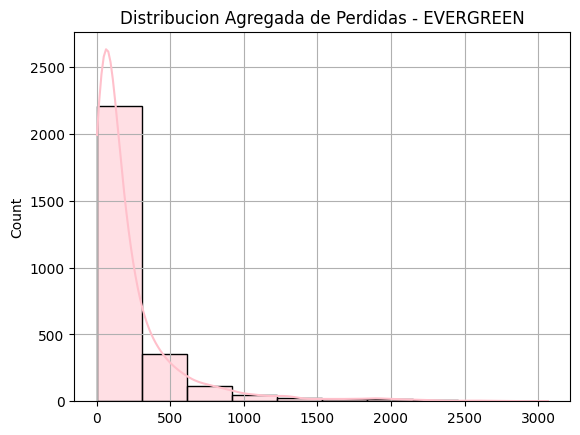

In [40]:
nxl="/content/drive/MyDrive/1. RiesgoOperacional_EVERGREEEN_Clase.xlsx"
XDB= pd.read_excel(nxl, sheet_name=0) #XDB es un dataframe

freq=XDB.iloc[:,3]
severidad=XDB.iloc[:,4]
LDA=freq*severidad

dff,uf,varf,desv,casf=MedidasDTC(freq, 10)
print("la media de la frecuencia es", uf)
print("la varianza de la frecuencia es", varf)
print("la desviacion estandar de la frecuencia es", desv)
print("el coeficiente de asimetria de la frecuencia es", casf)
print("Este es el histograma para la frecuencia")


dfs,us,vars,desvs,cass=MedidasDTC(severidad, 10)
print("Este es el histograma para la severidad")
print("la media de la severidad es", us)
print("la varianza de la severidad es", vars)
print("la desviacion estandar de la severidad es", desvs)
print("el coeficiente de asimetria de la severidad es", cass)

dfLDA,uLDA,varLDA,desvLDA,casLDA=MedidasDTC(LDA, 10)
print("Este es el histograma para la distribucion LDA")
print("la media del LDA es", uLDA)
print("la varianza del LDA es", varLDA)
print("la desviacion estandar del LDA es", desvLDA)
print("el coeficiente de asimetria del LDA es", casLDA)

plt.figure()
sns.histplot(LDA, color='pink', bins=10, kde=True)
plt.title('Distribucion Agregada de Perdidas - EVERGREEN')
plt.grid()
plt.show()

####**3. Analisis de resultados**

De acuerdo con lo anterior podemos observar en general que las variables Frecuencia (0.722), Severidad (2.969) y Distribucion de las perdidas (3.792) alcanzaron coeficientes de asimetria en general positivos. Esto indica que las periddas tienden a ubicarse por debajo de la media de las perdidas.
Se destaca que la distribucion de las perdidas tuvo en general el mayor coeficiente de asimetria, lo que indica que las perdidas al final no tendran un impacto significativo sobre las finanzas de una organizacion.
Es importante mencionar que estas distribuciones en general poseen estructuras esbeltas de cola larga, como se puede observar en l agrafica de la distribucion LDA (Loss Distribution Approach)